In [28]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

In [32]:
df_results = pd.read_csv("results.csv")
df_results["error_curve_cond"] = df_results["error_curve_cond"].apply(lambda f: np.array(json.loads(f)))
df_results

,openmlid,data_seed,num_instances,num_possible_ensemble_members,validation_size,max_num_samples_for_estimation,ensemble_sequence_seed,error_curve_cond
0,1049,0,100,8,8,10000,0,"[[-0.004553191200744903, -0.002668176758523775..."
1,1049,0,100,8,8,10000,1,"[[-0.004553191200744903, -0.002668176758523775..."
2,1049,0,100,8,8,10000,2,"[[-0.004553191200744903, -0.002668176758523775..."
3,1049,0,100,8,8,10000,3,"[[-0.004553191200744903, -0.002668176758523775..."
4,1049,0,100,8,8,10000,4,"[[-0.004553191200744903, -0.002668176758523775..."
5,1049,0,100,8,8,100000,0,"[[-0.004553191200744903, -0.002668176758523775..."
6,1049,0,100,8,8,100000,1,"[[-0.004553191200744903, -0.002668176758523775..."
7,1049,0,100,8,8,100000,2,"[[-0.004553191200744903, -0.002668176758523775..."
8,1049,0,100,8,8,100000,3,"[[-0.004553191200744903, -0.002668176758523775..."
9,1049,0,100,8,8,100000,4,"[[-0.004553191200744903, -0.002668176758523775..."


In [33]:
labels_cond = [
    r"$\text{cov}[\bar{\xi}^{11}, \bar{\xi}^{11}]$",
    r"$\text{cov}[\bar{\xi}^{12}, \bar{\xi}^{12}]$",
    r"$\text{cov}[\bar{\xi}^{11}, \bar{\xi}^{12}]$",
    r"$\text{cov}[\bar{\xi}^{11}, \bar{\xi}^{22}]$",
    r"$\text{cov}[\bar{\xi}^{12}, \bar{\xi}^{33}]$",
    r"$\text{cov}[\bar{\xi}^{12}, \bar{\xi}^{13}]$",
    r"$\text{cov}[\bar{\xi}^{12}, \bar{\xi}^{34}]$"
]
labels_iid = [
    r"$\text{cov}[\xi^{11}_1, \xi^{11}_1]$",
    r"$\text{cov}[\xi^{12}_1, \xi^{12}_1]$",
    r"$\text{cov}[\xi^{11}_1, \xi^{12}_1]$",
    r"$\text{cov}[\xi^{11}_1, \xi^{22}_1]$",
    r"$\text{cov}[\xi^{12}_1, \xi^{33}_1]$",
    r"$\text{cov}[\xi^{12}_1, \xi^{13}_1]$",
    r"$\text{cov}[\xi^{12}_1, \xi^{34}_1]$",
    r"$\text{cov}[\xi^{11}_1, \xi^{11}_2]$",
    r"$\text{cov}[\xi^{12}_1, \xi^{12}_2]$",
    r"$\text{cov}[\xi^{11}_1, \xi^{12}_2]$",
    r"$\text{cov}[\xi^{11}_1, \xi^{22}_2]$",
    r"$\text{cov}[\xi^{12}_1, \xi^{33}_2]$",
    r"$\text{cov}[\xi^{12}_1, \xi^{13}_2]$",
    r"$\text{cov}[\xi^{12}_1, \xi^{34}_2]$"
]

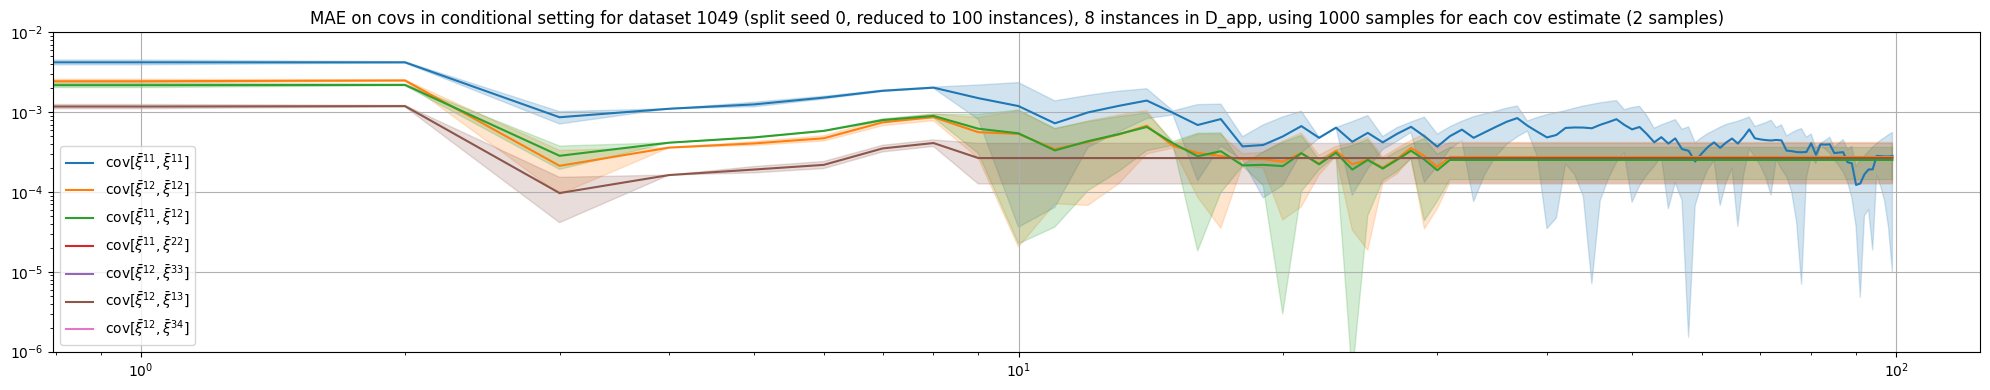

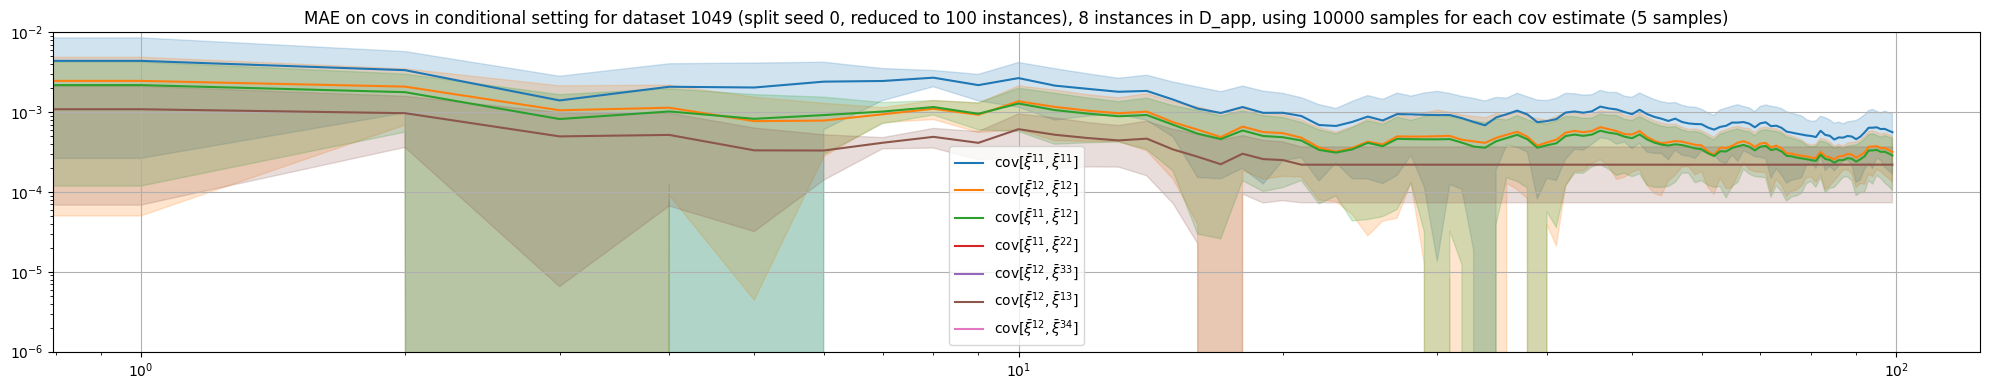

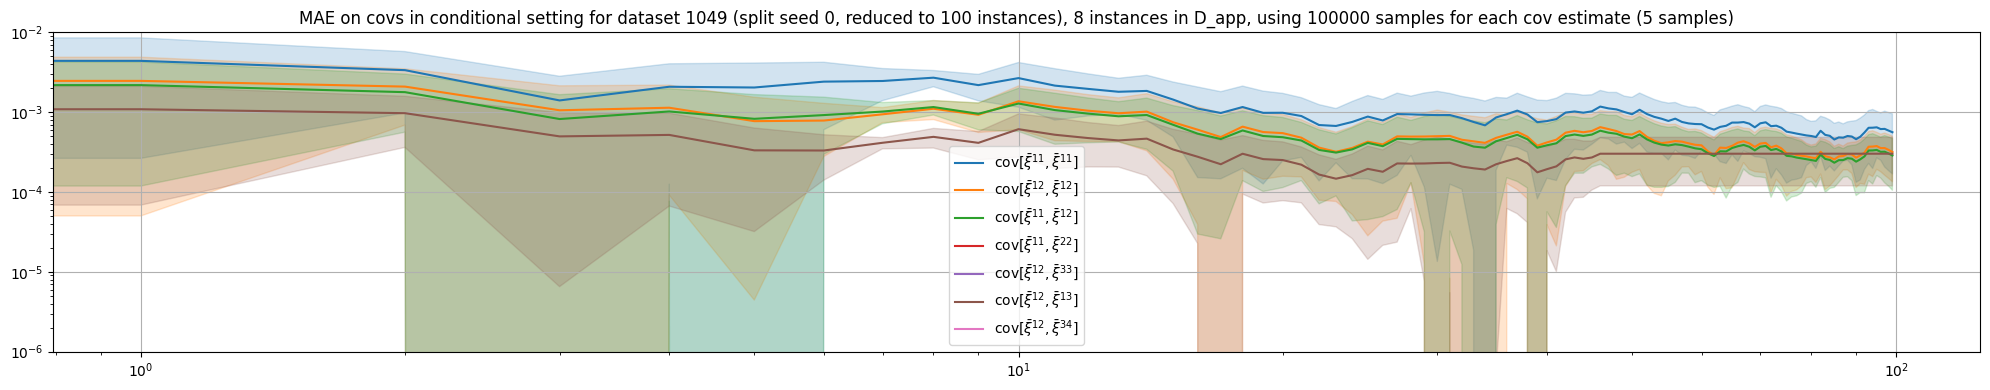

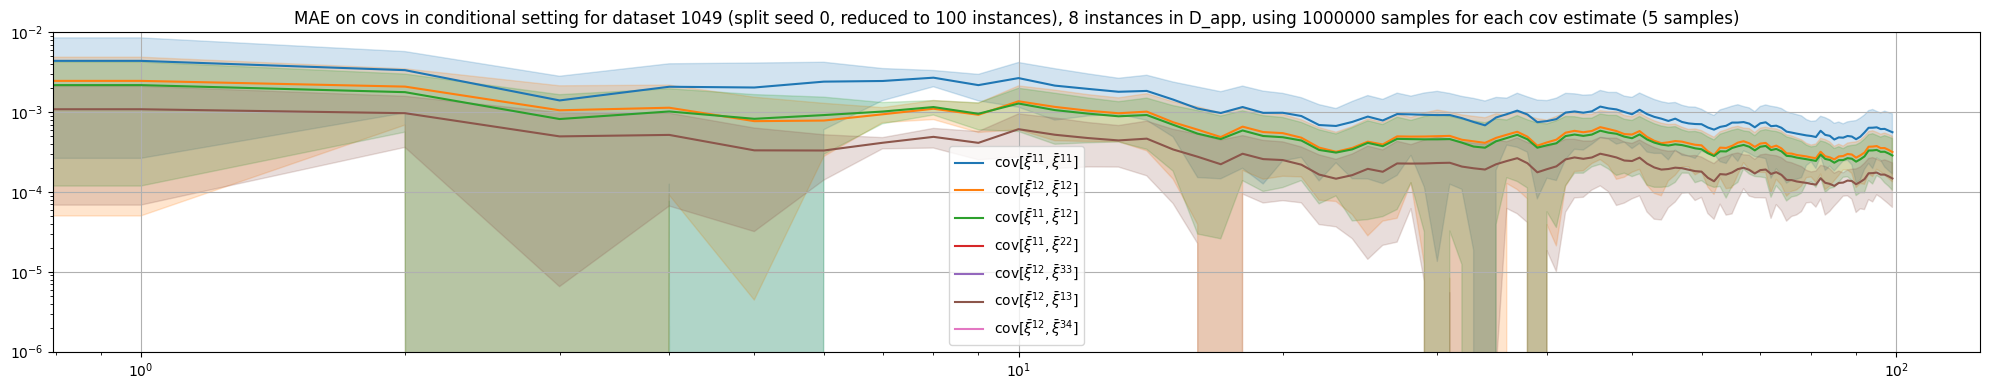

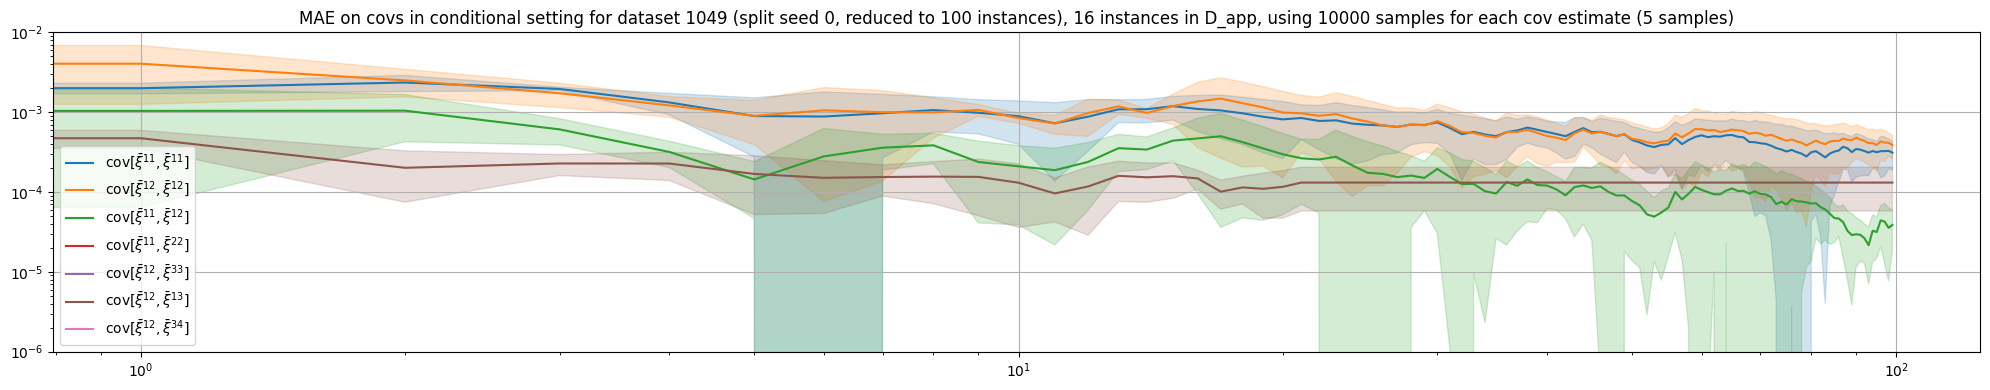

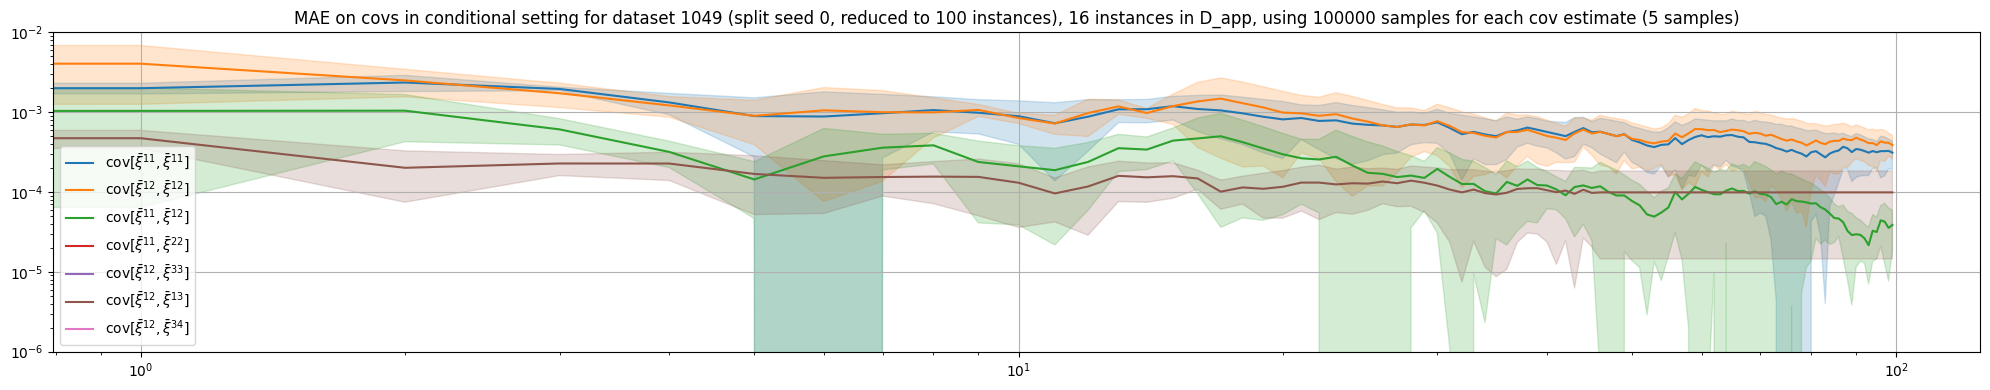

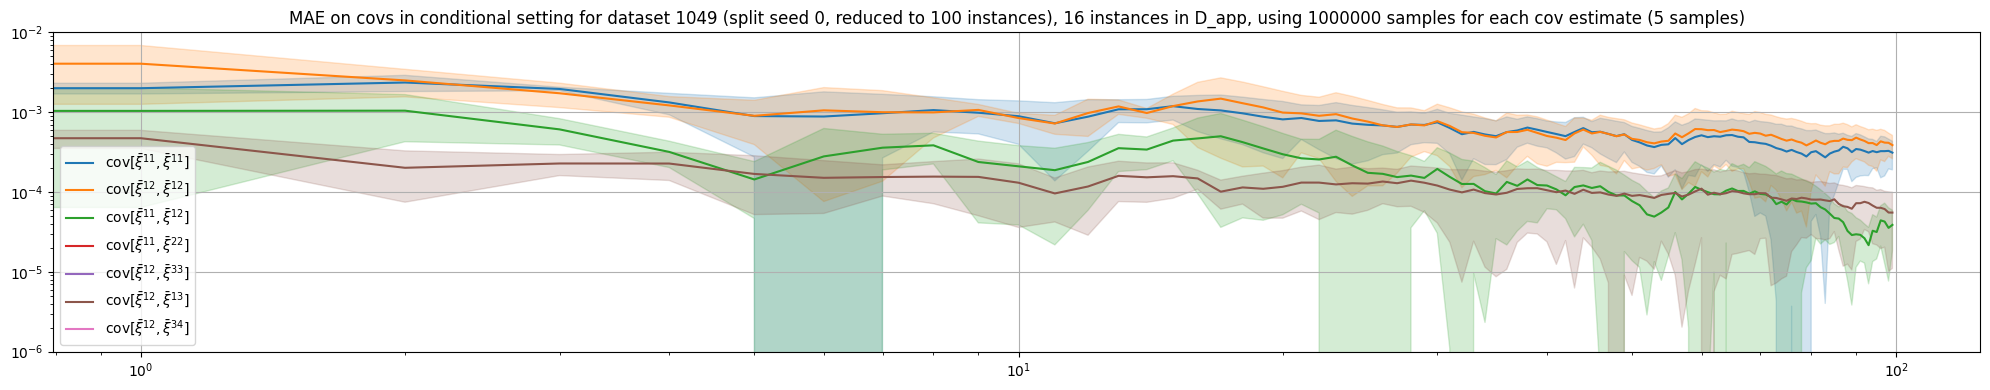

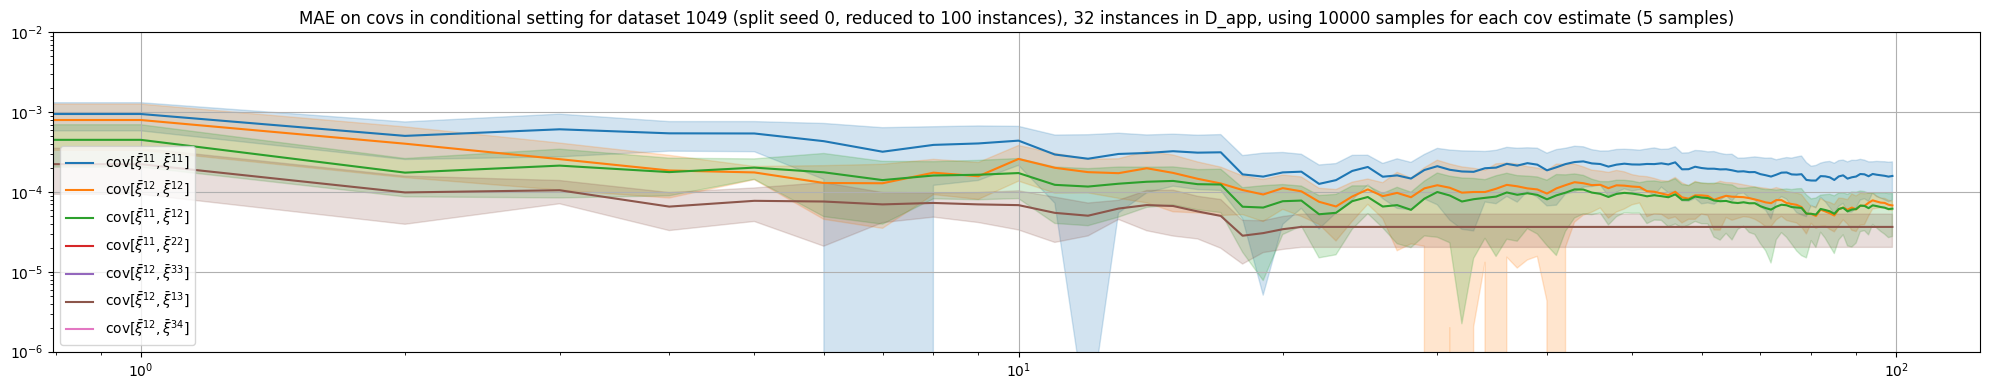

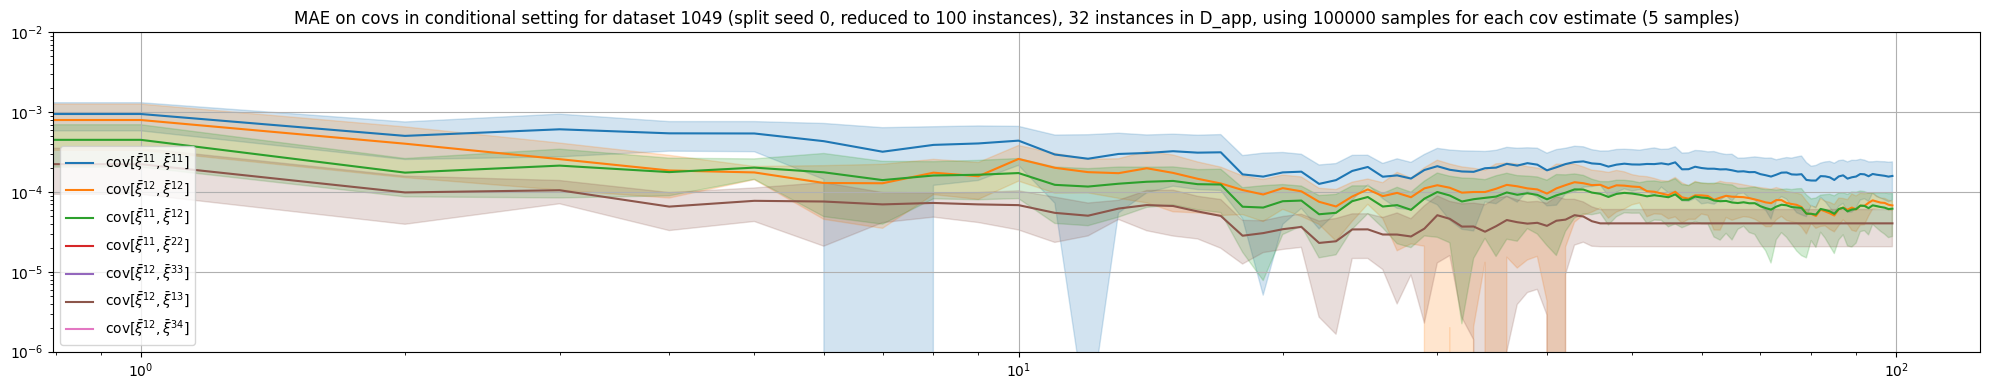

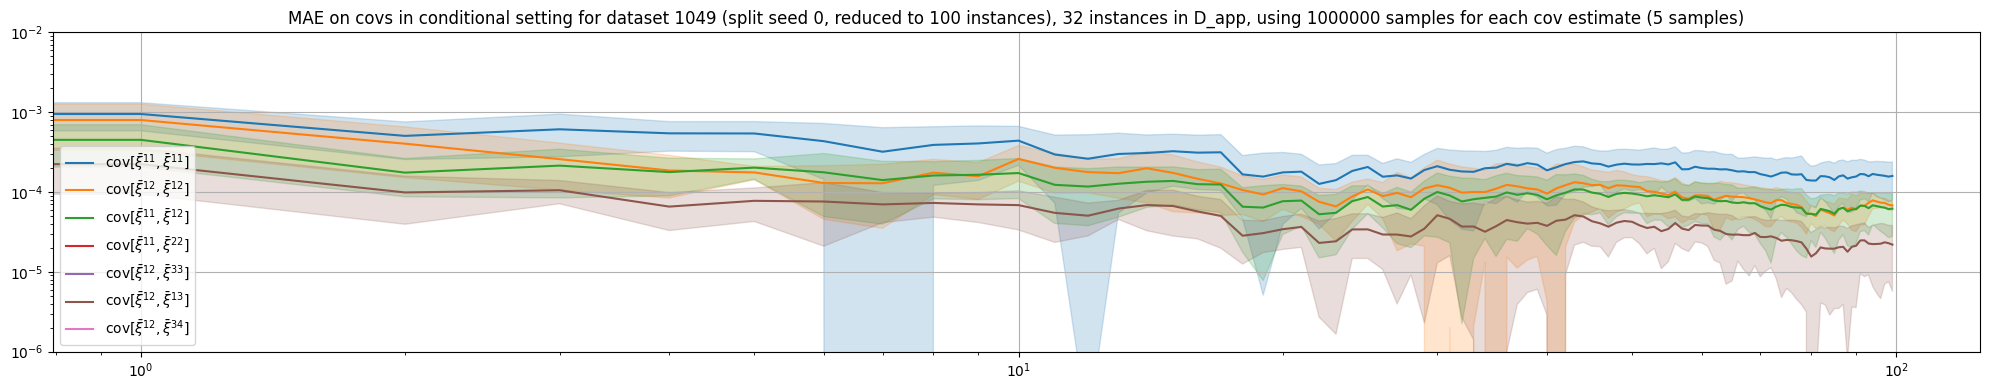

In [34]:
# show result
for context, df_context in df_results.groupby(["openmlid", "data_seed", "num_instances", "num_possible_ensemble_members", "validation_size", "max_num_samples_for_estimation"]):
    openmlid, data_seed, num_instances, num_possible_ensemble_members, validation_size, max_num_samples_for_estimation = context

    fig, ax = plt.subplots(figsize=(20, 4))
    error_curve_cond = np.abs(np.array(df_context["error_curve_cond"].tolist()).transpose(0, 2, 1))
    means = error_curve_cond.mean(axis=0)
    stds = error_curve_cond.std(axis=0)

    for i, (mean, std, label) in enumerate(zip(means, stds, labels_cond)):
        ax.plot(mean, label=label, color=f"C{i}")
        ax.fill_between(range(len(mean)), mean + std, mean - std, alpha=0.2, color=f"C{i}")
    #ax.axvline(max_num_samples_for_estimation, color="black", label="Begin Forget Zone")
    ax.legend()
    ax.set_title(f"MAE on covs in conditional setting for dataset {openmlid} (split seed {data_seed}, reduced to {num_instances} instances), {validation_size} instances in D_app, using {max_num_samples_for_estimation} samples for each cov estimate ({len(df_context)} samples)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim([10**-6, 10**-2])
    ax.grid()

    fig.tight_layout()
    plt.show()